# Basic EDA
- original_data/
  - Dataset_User_Agreement.pdf
  - Yelp Dataset Documentation & ToS copy.pdf
  - yelp_academic_dataset_business.json
  - yelp_academic_dataset_checkin.json
  - yelp_academic_dataset_review.json
  - yelp_academic_dataset_tip.json
  - yelp_academic_dataset_user.json
- custom_data/
  - yelp_categories.json = *categories for businesses scraped from the internet, more info in categories_scraping.ipynb*

In [1]:
import pandas as pd
from pathlib import Path
import seaborn as sns
from pprint import pp as pprint
import re
import json
from icecream import ic
from itertools import product
from matplotlib import pyplot as plt
from dateutil import parser
import datetime

In [2]:
YELP_RED = "#e00707"

In [3]:
with open("custom_data/yelp_categories.json") as f:
    file_content = f.read()
    categories_dict = json.loads(file_content)

categories = list()
def recur_get_categories(categories_dict: dict):
    for key, val in categories_dict.items():
        categories.append(key)
        for el in val:
            if type(el) == str:
                categories.append(el)
            if type(el) == dict:
                recur_get_categories(el)
recur_get_categories(categories_dict)
ic(len(categories))

ic| len(categories): 1484


1484

In [4]:
DATASET_PATH = Path("original_data/yelp_json")
CUSTOM_DATASET_PATH = Path("custom_data/")

## Business

In [5]:
business = pd.read_json(DATASET_PATH / "yelp_academic_dataset_business.json", lines=True)
business

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.426679,-119.711197,5.0,7,0,{'ByAppointmentOnly': 'True'},"Doctors, Traditional Chinese Medicine, Naturop...",None
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,87 Grasso Plaza Shopping Center,Affton,MO,63123,38.551126,-90.335695,3.0,15,1,{'BusinessAcceptsCreditCards': 'True'},"Shipping Centers, Local Services, Notaries, Ma...","{'Monday': '0:0-0:0', 'Tuesday': '8:0-18:30', ..."
2,tUFrWirKiKi_TAnsVWINQQ,Target,5255 E Broadway Blvd,Tucson,AZ,85711,32.223236,-110.880452,3.5,22,0,"{'BikeParking': 'True', 'BusinessAcceptsCredit...","Department Stores, Shopping, Fashion, Home & G...","{'Monday': '8:0-22:0', 'Tuesday': '8:0-22:0', ..."
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ..."
4,mWMc6_wTdE0EUBKIGXDVfA,Perkiomen Valley Brewery,101 Walnut St,Green Lane,PA,18054,40.338183,-75.471659,4.5,13,1,"{'BusinessAcceptsCreditCards': 'True', 'Wheelc...","Brewpubs, Breweries, Food","{'Wednesday': '14:0-22:0', 'Thursday': '16:0-2..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150341,IUQopTMmYQG-qRtBk-8QnA,Binh's Nails,3388 Gateway Blvd,Edmonton,AB,T6J 5H2,53.468419,-113.492054,3.0,13,1,"{'ByAppointmentOnly': 'False', 'RestaurantsPri...","Nail Salons, Beauty & Spas","{'Monday': '10:0-19:30', 'Tuesday': '10:0-19:3..."
150342,c8GjPIOTGVmIemT7j5_SyQ,Wild Birds Unlimited,2813 Bransford Ave,Nashville,TN,37204,36.115118,-86.766925,4.0,5,1,"{'BusinessAcceptsCreditCards': 'True', 'Restau...","Pets, Nurseries & Gardening, Pet Stores, Hobby...","{'Monday': '9:30-17:30', 'Tuesday': '9:30-17:3..."
150343,_QAMST-NrQobXduilWEqSw,Claire's Boutique,"6020 E 82nd St, Ste 46",Indianapolis,IN,46250,39.908707,-86.065088,3.5,8,1,"{'RestaurantsPriceRange2': '1', 'BusinessAccep...","Shopping, Jewelry, Piercing, Toy Stores, Beaut...",None
150344,mtGm22y5c2UHNXDFAjaPNw,Cyclery & Fitness Center,2472 Troy Rd,Edwardsville,IL,62025,38.782351,-89.950558,4.0,24,1,"{'BusinessParking': '{'garage': False, 'street...","Fitness/Exercise Equipment, Eyewear & Optician...","{'Monday': '9:0-20:0', 'Tuesday': '9:0-20:0', ..."


In [6]:
business.info()

<class 'pandas.DataFrame'>
RangeIndex: 150346 entries, 0 to 150345
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   business_id   150346 non-null  str    
 1   name          150346 non-null  str    
 2   address       150346 non-null  str    
 3   city          150346 non-null  str    
 4   state         150346 non-null  str    
 5   postal_code   150346 non-null  str    
 6   latitude      150346 non-null  float64
 7   longitude     150346 non-null  float64
 8   stars         150346 non-null  float64
 9   review_count  150346 non-null  int64  
 10  is_open       150346 non-null  int64  
 11  attributes    136602 non-null  object 
 12  categories    150243 non-null  str    
 13  hours         127123 non-null  object 
dtypes: float64(3), int64(2), object(2), str(7)
memory usage: 16.1+ MB


In [7]:
business.describe()

,latitude,longitude,stars,review_count,is_open
count,150346.000000,150346.000000,150346.000000,150346.000000,150346.00000
mean,36.671150,-89.357339,3.596724,44.866561,0.79615
std,5.872759,14.918502,0.974421,121.120136,0.40286
min,27.555127,-120.095137,1.000000,5.000000,0.00000
25%,32.187293,-90.357810,3.000000,8.000000,1.00000
50%,38.777413,-86.121179,3.500000,15.000000,1.00000
75%,39.954036,-75.421542,4.500000,37.000000,1.00000
max,53.679197,-73.200457,5.000000,7568.000000,1.00000


### Stars

[]

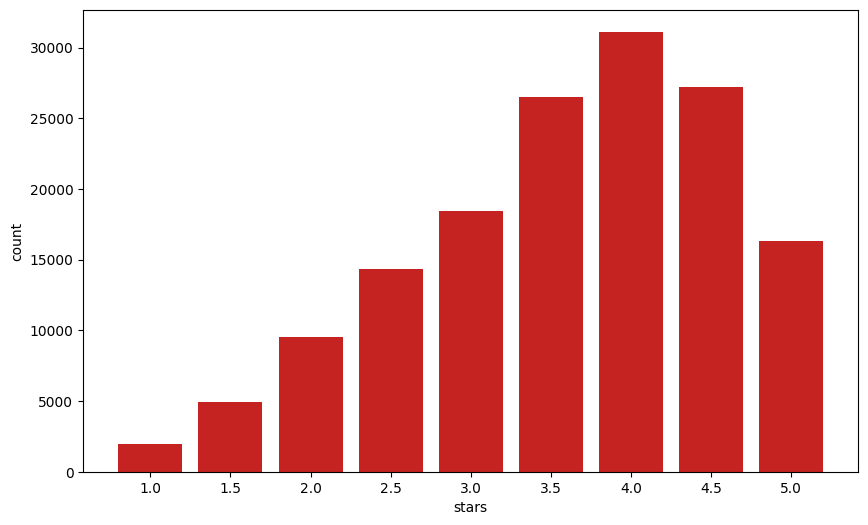

In [8]:
plt.figure(figsize=(10, 6))
sns.countplot(data=business, x="stars", color=YELP_RED)
plt.plot()

[]

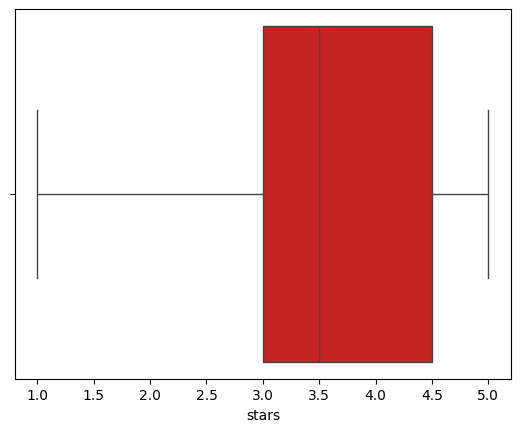

In [9]:
sns.boxplot(data=business, x="stars", color=YELP_RED)
plt.plot()

### Review Count

Text(0, 0.5, 'Number of restaurants')

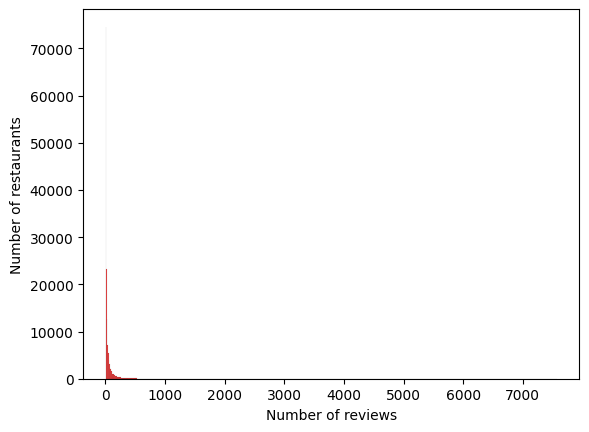

In [10]:
review_histplot = sns.histplot(data=business, x="review_count", color=YELP_RED)
review_histplot.set_xlabel("Number of reviews")
review_histplot.set_ylabel("Number of restaurants")

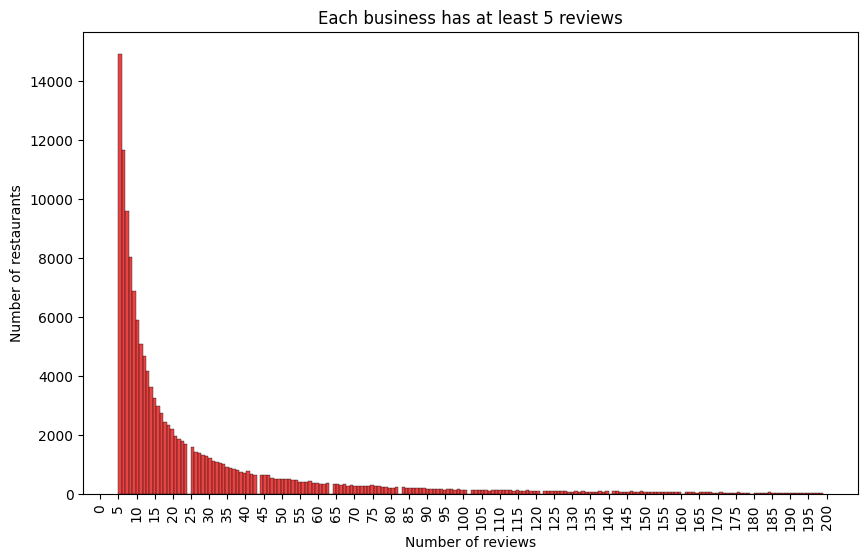

In [11]:
plt.figure(figsize=(10, 6))
review_histplot = sns.histplot(data=business[business["review_count"] < 200], x="review_count", color=YELP_RED)
review_histplot.set_xticks(range(0, 205, 5))
review_histplot.set_xlabel("Number of reviews")
review_histplot.set_ylabel("Number of restaurants")
review_histplot.set_title("Each business has at least 5 reviews")
plt.xticks(rotation=90)
plt.show()

### Open businesses

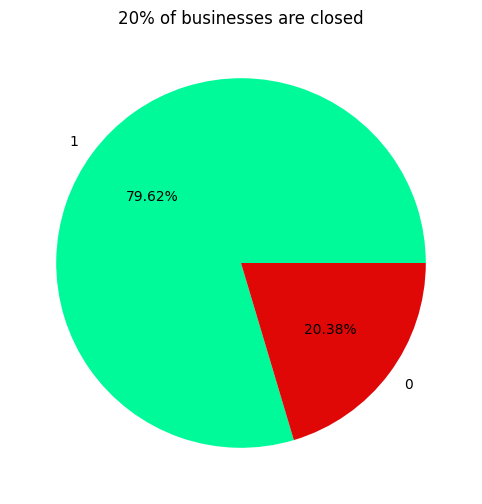

In [12]:
vc = business.value_counts("is_open")

def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct*total/100.0))
        return '{p:.1f}%\n({v:d} businesses)'.format(p=pct, v=val)
    return my_autopct

plt.figure(figsize=(10, 6))
plt.pie(
    vc.to_list(),
    labels=vc.index.to_list(),
    colors=["mediumspringgreen", YELP_RED],
    # autopct=make_autopct(vc.to_list()),
    autopct="%0.2f%%"
)
plt.title("20% of businesses are closed")
plt.show()

### Business locations

In [13]:
state_counts = business.value_counts("state", dropna=False)
pd.DataFrame({"state": state_counts.index, "count": state_counts.values, "count(%)": (100 * state_counts / state_counts.sum()).values})

,state,count,count(%)
0,PA,34039,22.640443
1,FL,26330,17.512937
2,TN,12056,8.018837
3,IN,11247,7.480744
4,MO,10913,7.258590
5,LA,9924,6.600774
6,AZ,9912,6.592793
7,NJ,8536,5.677570
8,NV,7715,5.131497
9,AB,5573,3.706783


All businesses are in the US, except for approximately 5500 businesses in Alberta (AB), Canada. There is also a single business in XMS. While XMS is not a standardised abbreviation, I was able to find out that it means Merseyside, a county in Northern England.

In [14]:
business[business["state"] == "XMS"]

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
98685,IvQs2hhXKZ4NgZhVZ5jjjQ,Pumpernickles Catering,95a Mount Pleasant,Liverpool,XMS,L3 5TB,38.673049,-90.423156,4.0,5,1,"{'RestaurantsPriceRange2': '2', 'BusinessParki...","Caterers, Breakfast & Brunch, Convenience Stor...",None


![attachment:merseyside](images/liverpool_XMS.png)

In [15]:
city_counts = business[["city", "state"]].value_counts()
city_counts = pd.DataFrame(
    {
        "city": [f"{city[0]}, {city[1]}" for city in city_counts.index],
        "count": city_counts.values,
        "count(%)": (100 * city_counts / city_counts.sum()).values
    }
)
city_counts

,city,count,count(%)
0,"Philadelphia, PA",14567,9.688984
1,"Tucson, AZ",9249,6.151810
2,"Tampa, FL",9048,6.018118
3,"Indianapolis, IN",7540,5.015099
4,"Nashville, TN",6968,4.634643
...,...,...,...
1462,"Slidell, LA",1,0.000665
1463,"Wales, PA",1,0.000665
1464,"UPPER MORELAND, PA",1,0.000665
1465,"Aston, DE",1,0.000665


We have most data for Philadelphia (PA), Tucson (AZ), Tampa (FL), Indianapolis (IN), and so on.

### Business types (categories)

Categories are basically long strings, wherein each category is separated by a comma.

In [16]:
business["categories"].head()

0    Doctors, Traditional Chinese Medicine, Naturop...
1    Shipping Centers, Local Services, Notaries, Ma...
2    Department Stores, Shopping, Fashion, Home & G...
3    Restaurants, Food, Bubble Tea, Coffee & Tea, B...
4                            Brewpubs, Breweries, Food
Name: categories, dtype: str

Some categories, however, have a comma in their name.

In [17]:
categories_with_comma = list(filter(lambda category: "," in category, categories))
pprint(categories_with_comma)

['Beer, Wine & Spirits',
 'Wills, Trusts, & Probates',
 'Books, Mags, Music & Video',
 'Used, Vintage & Consignment']


In [18]:
new_business_categories_list = list()
for business_categories in business["categories"]:
    # if a category name contains a comma, replace it with a semicolon
    if type(business_categories) == str:
        for category_with_comma in categories_with_comma:
            business_categories = business_categories.replace(category_with_comma, category_with_comma.replace(",", ";"))
    new_business_categories_list.append(business_categories)

new_business_categories_to_add = list()
for new_business_categories in new_business_categories_list:
    if type(new_business_categories) == str:
        new_business_categories = new_business_categories.split(",")
    elif type(new_business_categories) == float:
        new_business_categories = list()
    # getting rid of trailing whitespaces
    new_business_categories_to_add.append([new_business_category.strip() for new_business_category in new_business_categories])

business["new_categories"] = new_business_categories_to_add

In [19]:
business.head()

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours,new_categories
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.426679,-119.711197,5.0,7,0,{'ByAppointmentOnly': 'True'},"Doctors, Traditional Chinese Medicine, Naturop...",None,"[Doctors, Traditional Chinese Medicine, Naturo..."
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,87 Grasso Plaza Shopping Center,Affton,MO,63123,38.551126,-90.335695,3.0,15,1,{'BusinessAcceptsCreditCards': 'True'},"Shipping Centers, Local Services, Notaries, Ma...","{'Monday': '0:0-0:0', 'Tuesday': '8:0-18:30', ...","[Shipping Centers, Local Services, Notaries, M..."
2,tUFrWirKiKi_TAnsVWINQQ,Target,5255 E Broadway Blvd,Tucson,AZ,85711,32.223236,-110.880452,3.5,22,0,"{'BikeParking': 'True', 'BusinessAcceptsCredit...","Department Stores, Shopping, Fashion, Home & G...","{'Monday': '8:0-22:0', 'Tuesday': '8:0-22:0', ...","[Department Stores, Shopping, Fashion, Home & ..."
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ...","[Restaurants, Food, Bubble Tea, Coffee & Tea, ..."
4,mWMc6_wTdE0EUBKIGXDVfA,Perkiomen Valley Brewery,101 Walnut St,Green Lane,PA,18054,40.338183,-75.471659,4.5,13,1,"{'BusinessAcceptsCreditCards': 'True', 'Wheelc...","Brewpubs, Breweries, Food","{'Wednesday': '14:0-22:0', 'Thursday': '16:0-2...","[Brewpubs, Breweries, Food]"


Not all possible YELP categories are present in our dataset.

In [20]:
unique_categories = set()
for business_row in business["new_categories"]:
    for category in business_row:
        unique_categories.add(category)
ic(len(categories) - len(unique_categories))

ic| len(categories) - len(unique_categories): 179


179

In [21]:
# one hot indexing all the categories
new_category_labels_dict = dict()
for unique_category in unique_categories:
    unique_category_one_hot = [int(unique_category in categories) for categories in business["new_categories"]]

    new_category_labels_dict[f"{unique_category}_category"] = unique_category_one_hot
business = business.assign(**new_category_labels_dict)
business = business.copy()

/tmp/ipykernel_20631/21377948.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  business = business.assign(**new_category_labels_dict)


In [22]:
business.head(10)

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,...,Pretzels_category,Pool Cleaners_category,Pet Breeders_category,Soul Food_category,Prosthodontists_category,Decks & Railing_category,Pet Cremation Services_category,Poutineries_category,Apartments_category,Moroccan_category
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.426679,-119.711197,5.0,7,...,0,0,0,0,0,0,0,0,0,0
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,87 Grasso Plaza Shopping Center,Affton,MO,63123,38.551126,-90.335695,3.0,15,...,0,0,0,0,0,0,0,0,0,0
2,tUFrWirKiKi_TAnsVWINQQ,Target,5255 E Broadway Blvd,Tucson,AZ,85711,32.223236,-110.880452,3.5,22,...,0,0,0,0,0,0,0,0,0,0
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,0,0,0,0,0,0,0,0,0,0
4,mWMc6_wTdE0EUBKIGXDVfA,Perkiomen Valley Brewery,101 Walnut St,Green Lane,PA,18054,40.338183,-75.471659,4.5,13,...,0,0,0,0,0,0,0,0,0,0
5,CF33F8-E6oudUQ46HnavjQ,Sonic Drive-In,615 S Main St,Ashland City,TN,37015,36.269593,-87.058943,2.0,6,...,0,0,0,0,0,0,0,0,0,0
6,n_0UpQx1hsNbnPUSlodU8w,Famous Footwear,"8522 Eager Road, Dierbergs Brentwood Point",Brentwood,MO,63144,38.627695,-90.340465,2.5,13,...,0,0,0,0,0,0,0,0,0,0
7,qkRM_2X51Yqxk3btlwAQIg,Temple Beth-El,400 Pasadena Ave S,St. Petersburg,FL,33707,27.766590,-82.732983,3.5,5,...,0,0,0,0,0,0,0,0,0,0
8,k0hlBqXX-Bt0vf1op7Jr1w,Tsevi's Pub And Grill,8025 Mackenzie Rd,Affton,MO,63123,38.565165,-90.321087,3.0,19,...,0,0,0,0,0,0,0,0,0,0
9,bBDDEgkFA1Otx9Lfe7BZUQ,Sonic Drive-In,2312 Dickerson Pike,Nashville,TN,37207,36.208102,-86.768170,1.5,10,...,0,0,0,0,0,0,0,0,0,0


In [23]:
popular_categories = business.filter(like="_category", axis=1).sum(axis=0, numeric_only=True).sort_values(ascending=False)

In [24]:
pd.DataFrame(
    {
        "category": popular_categories.index,
        "count": popular_categories.values,
        "count(%)": (100 * popular_categories / len(business)).values
    }
)

,category,count,count(%)
0,Restaurants_category,52268,34.765142
1,Food_category,27781,18.478044
2,Shopping_category,24395,16.225906
3,Home Services_category,14356,9.548641
4,Beauty & Spas_category,14292,9.506073
...,...,...,...
1300,Bike Parking_category,1,0.000665
1301,Fuzhou_category,1,0.000665
1302,Lahmacun_category,1,0.000665
1303,Sport Equipment Hire_category,1,0.000665


### Attributes

In [25]:
all_possible_attributes = dict()
for attribute_dict in business["attributes"].dropna():
    for key, val in attribute_dict.items():
        if key not in all_possible_attributes.keys():
            all_possible_attributes[key] = set()
        all_possible_attributes[key].add(val)
pprint(all_possible_attributes)

{'ByAppointmentOnly': {'True', 'False', 'None'},
 'BusinessAcceptsCreditCards': {'True', 'False', 'None'},
 'BikeParking': {'True', 'False', 'None'},
 'RestaurantsPriceRange2': {'4', '1', '2', 'None', '3'},
 'CoatCheck': {'True', 'False', 'None'},
 'RestaurantsTakeOut': {'True', 'False', 'None'},
 'RestaurantsDelivery': {'True', 'False', 'None'},
 'Caters': {'True', 'False', 'None'},
 'WiFi': {"u'free'", "u'paid'", "'paid'", "u'no'", "'free'", 'None', "'no'"},
 'BusinessParking': {'None',
                     "{'garage': False, 'street': False, 'validated': False, "
                     "'lot': False, 'valet': False}",
                     "{'garage': False, 'street': False, 'validated': False, "
                     "'lot': False, 'valet': True}",
                     "{'garage': False, 'street': False, 'validated': False, "
                     "'lot': None, 'valet': False}",
                     "{'garage': False, 'street': False, 'validated': False, "
                     "'lot': T

### Hours

The `hours` column contains a dict with workdays and their respective openings and closings.

In [26]:
{key for business_hours_dict in business["hours"].dropna() for key in list(business_hours_dict.keys())}

{'Friday', 'Monday', 'Saturday', 'Sunday', 'Thursday', 'Tuesday', 'Wednesday'}

In [27]:
{val for business_hours_dict in business["hours"].dropna() for val in list(business_hours_dict.values())}

{'8:15-13:30',
 '12:30-3:30',
 '19:0-23:0',
 '15:30-0:30',
 '8:45-21:30',
 '16:30-19:30',
 '21:0-0:0',
 '22:0-6:0',
 '0:30-1:0',
 '9:15-16:15',
 '5:0-8:0',
 '16:45-19:15',
 '12:0-18:45',
 '20:0-6:0',
 '12:0-22:45',
 '6:0-1:20',
 '21:30-21:45',
 '16:15-19:30',
 '8:0-2:45',
 '15:30-17:30',
 '10:0-1:30',
 '14:0-23:0',
 '0:0-14:0',
 '16:30-21:30',
 '11:0-22:15',
 '16:0-21:0',
 '5:45-20:15',
 '10:45-21:45',
 '7:0-10:0',
 '8:30-11:30',
 '0:30-0:0',
 '11:15-22:45',
 '13:0-18:0',
 '6:0-0:30',
 '10:30-20:45',
 '16:45-21:45',
 '17:0-21:0',
 '9:15-11:15',
 '4:0-3:0',
 '23:15-4:0',
 '17:0-20:0',
 '23:0-17:0',
 '6:30-2:0',
 '16:0-17:30',
 '5:30-11:30',
 '11:15-17:0',
 '22:30-19:30',
 '13:15-21:0',
 '8:0-10:15',
 '16:30-17:45',
 '22:0-22:0',
 '18:45-21:0',
 '7:30-11:30',
 '7:30-15:30',
 '21:30-0:0',
 '20:30-23:0',
 '11:0-23:15',
 '5:30-16:30',
 '13:15-17:0',
 '4:45-21:30',
 '8:30-15:45',
 '9:0-16:15',
 '6:0-14:30',
 '15:0-22:45',
 '22:0-19:0',
 '10:0-2:45',
 '7:0-20:0',
 '8:30-5:0',
 '6:0-6:0',
 '16

In [28]:
weekdays = ("Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday")
actions = ("opening", "closing")
time_units = ("hour", "minute")

# create a dictionary to add to the business dataframe
business_hours_to_add = {f"{weekday.lower()}_{action}_{time_unit}": [] for weekday, action, time_unit in product(weekdays, actions, time_units)}

timestamp_regex = re.compile(r"(\d{1,2}):(\d{1,2})-(\d{1,2}):(\d{1,2})")

for business_hours_dict in business["hours"]:
    for key in business_hours_to_add.keys():
        business_hours_to_add[key].append(None)
    if type(business_hours_dict) == dict:
        for key, val in business_hours_dict.items():
            timestamp_match = re.search(timestamp_regex, val)
            opening_hour = timestamp_match.group(1)
            opening_minute = timestamp_match.group(2)
            closing_hour = timestamp_match.group(3)
            closing_minute = timestamp_match.group(4)
            business_hours_to_add[f"{key.lower()}_opening_hour"][-1] = int(opening_hour)
            business_hours_to_add[f"{key.lower()}_opening_minute"][-1] = int(opening_minute)
            business_hours_to_add[f"{key.lower()}_closing_hour"][-1] = int(closing_hour)
            business_hours_to_add[f"{key.lower()}_closing_minute"][-1] = int(closing_minute)

business = business.assign(**business_hours_to_add)

# change datatype for the added columns
for time_column in business_hours_to_add.keys():
    business = business.astype({time_column: "Int32"})

In [29]:
business.filter(like="day_").head()

,sunday_opening_hour,sunday_opening_minute,sunday_closing_hour,sunday_closing_minute,monday_opening_hour,monday_opening_minute,monday_closing_hour,monday_closing_minute,tuesday_opening_hour,tuesday_opening_minute,...,thursday_closing_hour,thursday_closing_minute,friday_opening_hour,friday_opening_minute,friday_closing_hour,friday_closing_minute,saturday_opening_hour,saturday_opening_minute,saturday_closing_hour,saturday_closing_minute
0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,<NA>,<NA>,<NA>,<NA>,0,0,0,0,8,0,...,18,30,8,0,18,30,8,0,14,0
2,8,0,22,0,8,0,22,0,8,0,...,22,0,8,0,23,0,8,0,23,0
3,7,0,21,0,7,0,20,0,7,0,...,20,0,7,0,21,0,7,0,21,0
4,12,0,18,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,22,0,12,0,22,0,12,0,22,0


In [30]:
for weekday, action in product(weekdays, actions):
    business[f"{weekday.lower()}_{action}"] = business[f"{weekday.lower()}_{action}_hour"] + business[f"{weekday.lower()}_{action}_minute"] / 60
business = business.copy()

/tmp/ipykernel_20631/3513026258.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  business[f"{weekday.lower()}_{action}"] = business[f"{weekday.lower()}_{action}_hour"] + business[f"{weekday.lower()}_{action}_minute"] / 60


In [31]:
business.head()

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,...,tuesday_opening,tuesday_closing,wednesday_opening,wednesday_closing,thursday_opening,thursday_closing,friday_opening,friday_closing,saturday_opening,saturday_closing
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.426679,-119.711197,5.0,7,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,87 Grasso Plaza Shopping Center,Affton,MO,63123,38.551126,-90.335695,3.0,15,...,8.0,18.5,8.0,18.5,8.0,18.5,8.0,18.5,8.0,14.0
2,tUFrWirKiKi_TAnsVWINQQ,Target,5255 E Broadway Blvd,Tucson,AZ,85711,32.223236,-110.880452,3.5,22,...,8.0,22.0,8.0,22.0,8.0,22.0,8.0,23.0,8.0,23.0
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,7.0,20.0,7.0,20.0,7.0,20.0,7.0,21.0,7.0,21.0
4,mWMc6_wTdE0EUBKIGXDVfA,Perkiomen Valley Brewery,101 Walnut St,Green Lane,PA,18054,40.338183,-75.471659,4.5,13,...,<NA>,<NA>,14.0,22.0,16.0,22.0,12.0,22.0,12.0,22.0


Now, visualisations of opening and closing times throughout the week.

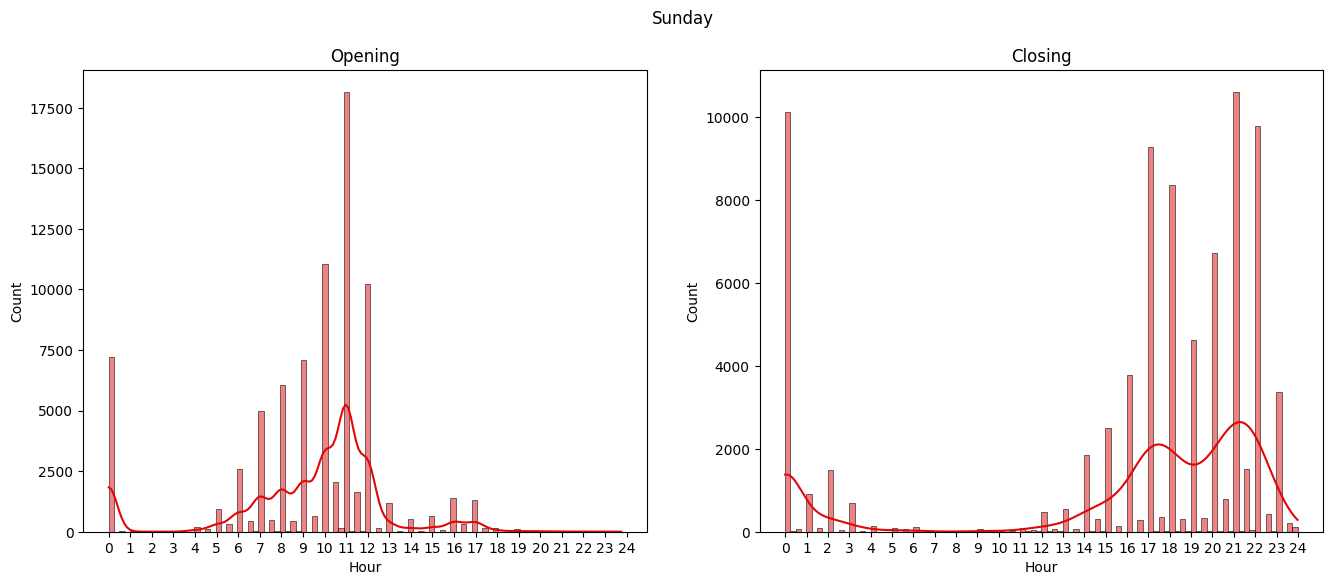

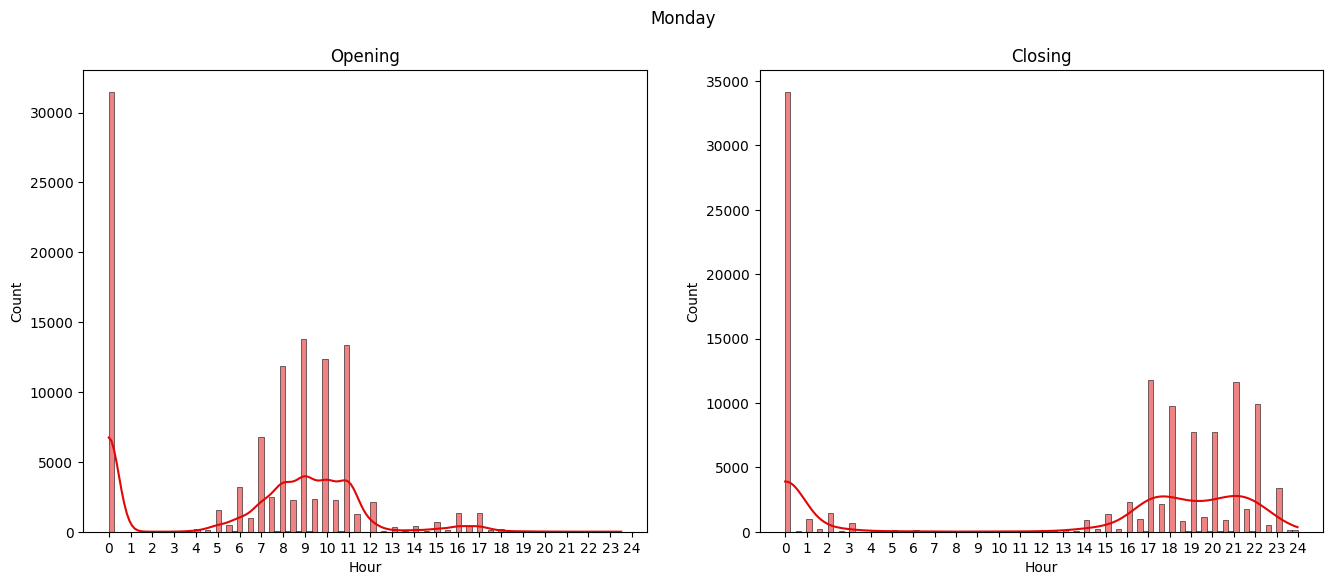

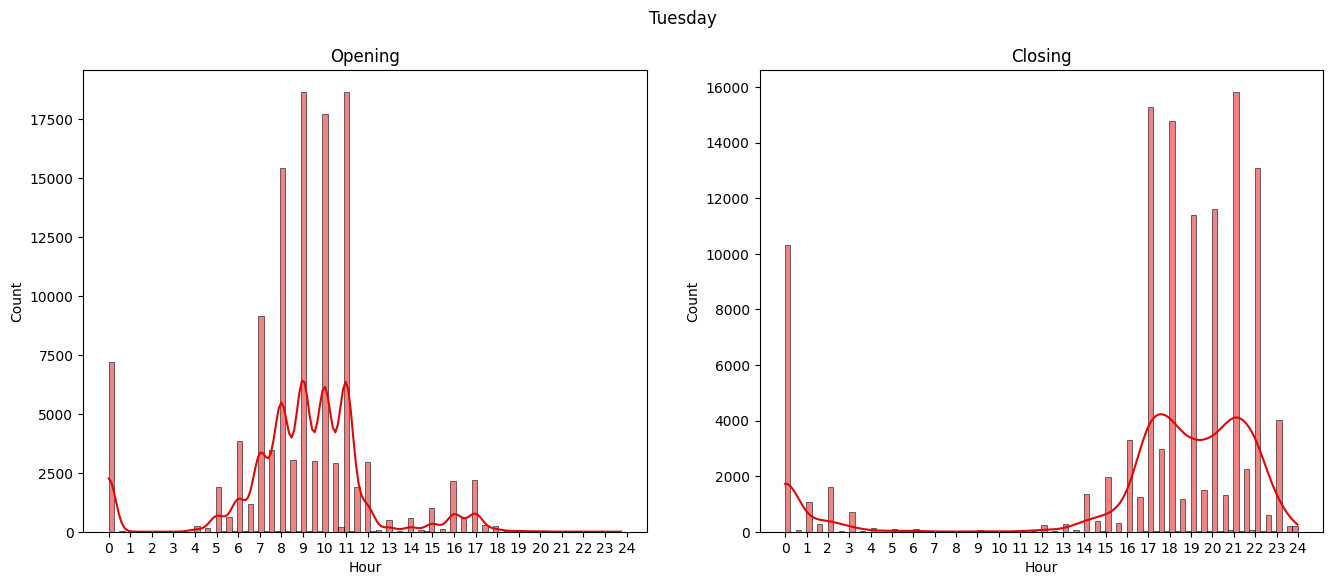

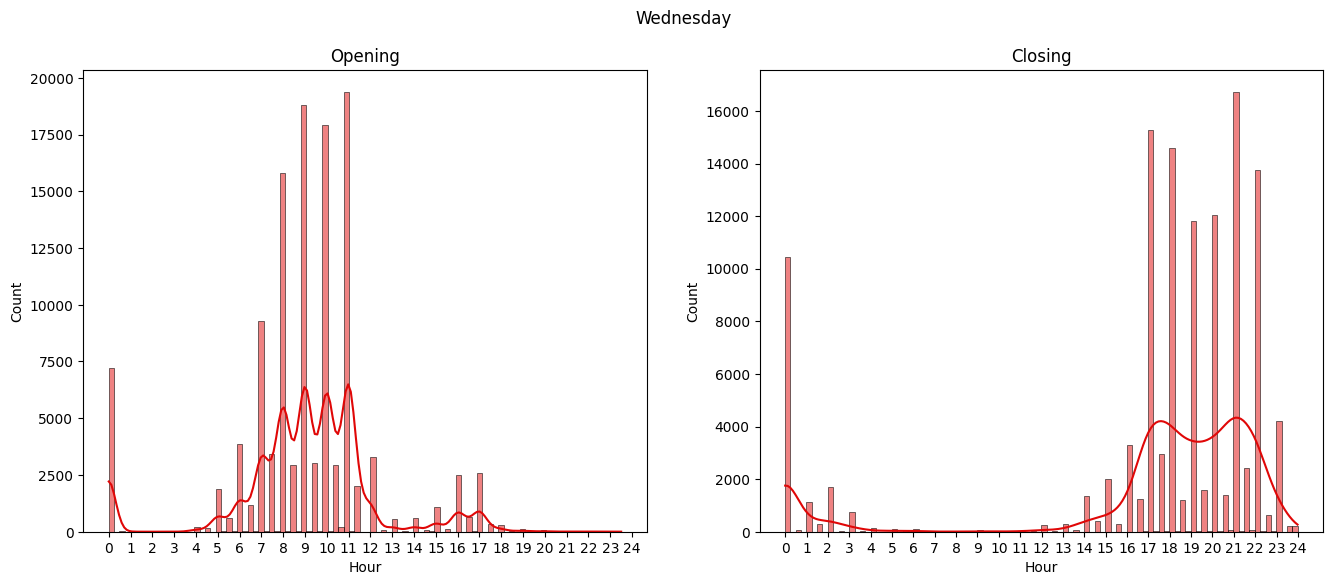

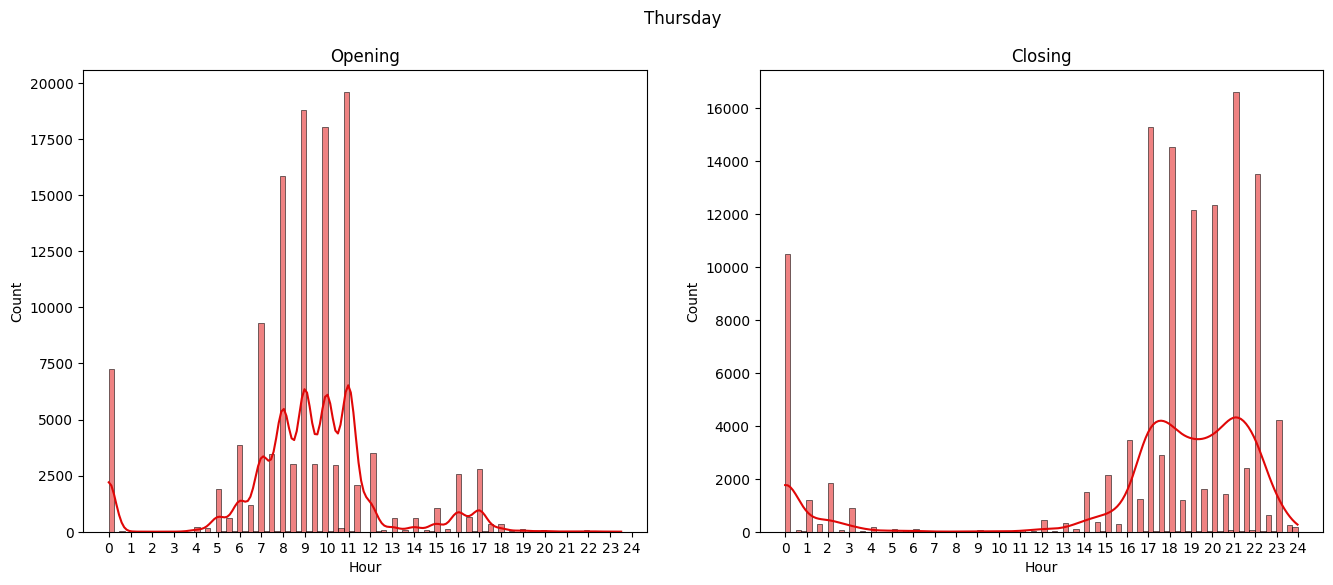

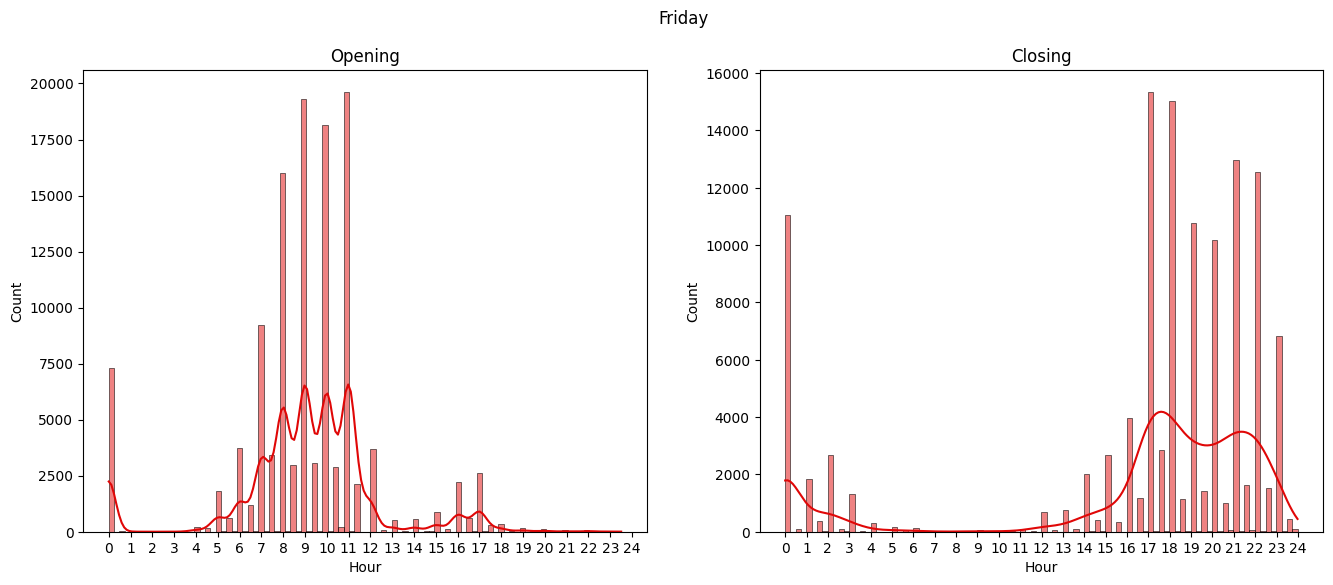

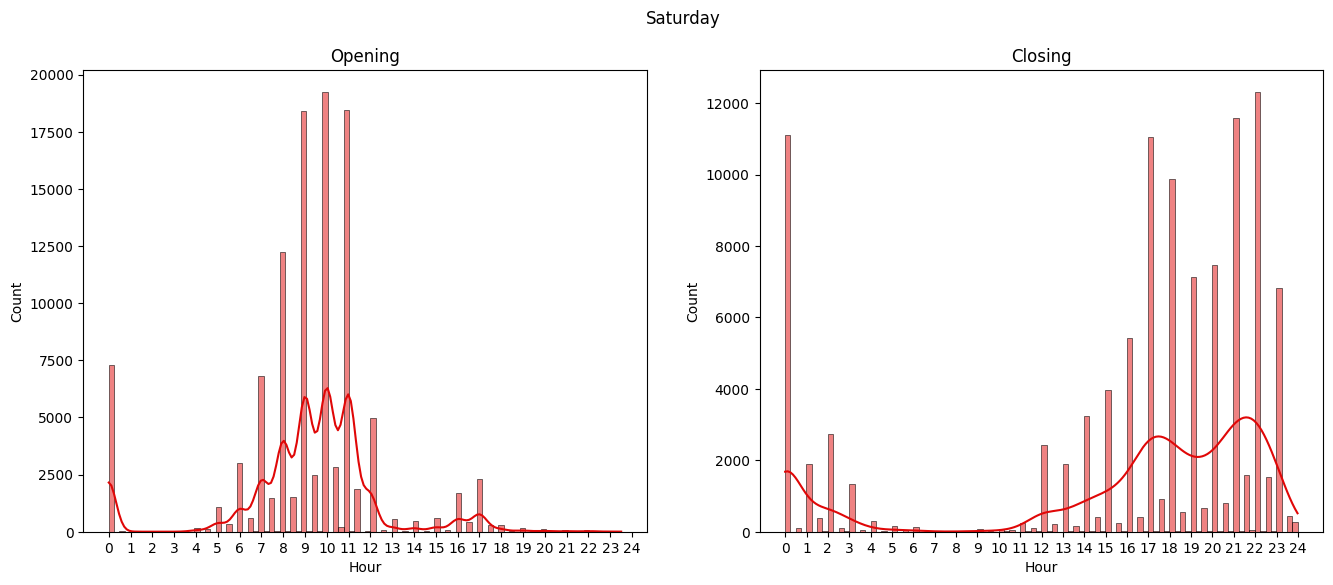

In [32]:
for weekday in weekdays:
    fig, (ax_open, ax_close) = plt.subplots(1, 2, figsize=(16, 6))
    for ax, action in zip((ax_open, ax_close), actions):
        to_plot = sns.histplot(
            data=business,
            x=f"{weekday.lower()}_{action}",
            bins=4*24,
            kde=True,
            ax=ax,
            color=YELP_RED
        )
        to_plot.set_title(action.capitalize())
        to_plot.set_xlabel("Hour")
        to_plot.set_xticks(range(0, 25))
    fig.suptitle(weekday)
    plt.plot()


## Checkin

In [33]:
checkin = pd.read_json(DATASET_PATH / "yelp_academic_dataset_checkin.json", lines=True)
checkin.head()

,business_id,date
0,---kPU91CF4Lq2-WlRu9Lw,"2020-03-13 21:10:56, 2020-06-02 22:18:06, 2020..."
1,--0iUa4sNDFiZFrAdIWhZQ,"2010-09-13 21:43:09, 2011-05-04 23:08:15, 2011..."
2,--30_8IhuyMHbSOcNWd6DQ,"2013-06-14 23:29:17, 2014-08-13 23:20:22"
3,--7PUidqRWpRSpXebiyxTg,"2011-02-15 17:12:00, 2011-07-28 02:46:10, 2012..."
4,--7jw19RH9JKXgFohspgQw,"2014-04-21 20:42:11, 2014-04-28 21:04:46, 2014..."


In [34]:
# separated_dates_lists = [date_row.split(",") for date_row in checkin["date"]]
# dates = [[parser.parse(separated_date.strip()) for separated_date in separated_dates] for separated_dates in separated_dates_lists]
# checkin = checkin.assign(dates=dates)

In [35]:
# checkin.head()

In [36]:
checkin.info()

<class 'pandas.DataFrame'>
RangeIndex: 131930 entries, 0 to 131929
Data columns (total 2 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   business_id  131930 non-null  str  
 1   date         131930 non-null  str  
dtypes: str(2)
memory usage: 2.0 MB


In [37]:
# dates = [date for date_list in checkin["dates"].to_list() for date in date_list]

In [38]:
# len(dates)

In [39]:
# sns.histplot(data=dates, color=YELP_RED)

## Review

WARNING: This is a modified version of reviews without the `text` column.

In [40]:
review = pd.read_csv(CUSTOM_DATASET_PATH / "review_for_vis.csv")
review

,review_id,user_id,business_id,stars,useful,funny,cool,date,text_length
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3,0,0,0,2018-07-07 22:09:11,513
1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5,1,0,1,2012-01-03 15:28:18,829
2,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3,0,0,0,2014-02-05 20:30:30,339
3,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5,1,0,1,2015-01-04 00:01:03,243
4,Sx8TMOWLNuJBWer-0pcmoA,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4,1,0,1,2017-01-14 20:54:15,534
...,...,...,...,...,...,...,...,...,...
6990275,H0RIamZu0B0Ei0P4aeh3sQ,qskILQ3k0I_qcCMI-k6_QQ,jals67o91gcrD4DC81Vk6w,5,1,2,1,2014-12-17 21:45:20,322
6990276,shTPgbgdwTHSuU67mGCmZQ,Zo0th2m8Ez4gLSbHftiQvg,2vLksaMmSEcGbjI5gywpZA,5,2,1,2,2021-03-31 16:55:10,397
6990277,YNfNhgZlaaCO5Q_YJR4rEw,mm6E4FbCMwJmb7kPDZ5v2Q,R1khUUxidqfaJmcpmGd4aw,4,1,0,0,2019-12-30 03:56:30,467
6990278,i-I4ZOhoX70Nw5H0FwrQUA,YwAMC-jvZ1fvEUum6QkEkw,Rr9kKArrMhSLVE9a53q-aA,5,1,0,0,2022-01-19 18:59:27,2317


In [41]:
review.info()

<class 'pandas.DataFrame'>
RangeIndex: 6990280 entries, 0 to 6990279
Data columns (total 9 columns):
 #   Column       Dtype
---  ------       -----
 0   review_id    str  
 1   user_id      str  
 2   business_id  str  
 3   stars        int64
 4   useful       int64
 5   funny        int64
 6   cool         int64
 7   date         str  
 8   text_length  int64
dtypes: int64(5), str(4)
memory usage: 480.0 MB


In [42]:
review.describe()

,stars,useful,funny,cool,text_length
count,6.990280e+06,6.990280e+06,6.990280e+06,6.990280e+06,6.990280e+06
mean,3.748584e+00,1.184609e+00,3.265596e-01,4.986175e-01,5.677644e+02
std,1.478705e+00,3.253767e+00,1.688729e+00,2.172460e+00,5.272578e+02
min,1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00,1.000000e+00
25%,3.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.290000e+02
50%,4.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.060000e+02
75%,5.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,7.200000e+02
max,5.000000e+00,1.182000e+03,7.920000e+02,4.040000e+02,5.000000e+03


### Date

In [43]:
timestamp_format = "%Y-%m-%d %H:%M:%S"
review_dates = [datetime.datetime.strptime(timestamp, timestamp_format).date() for timestamp in review["date"].to_list()]

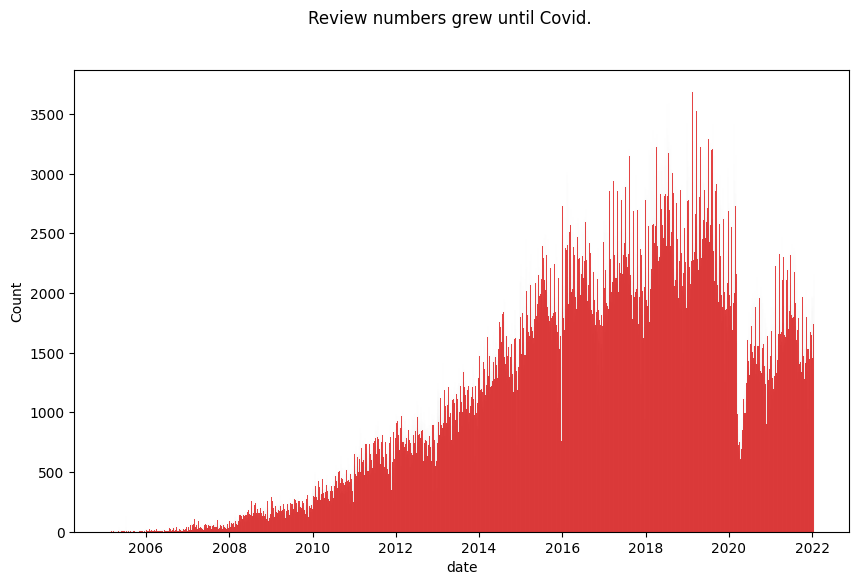

In [44]:
plt.figure(figsize=(10, 6))
fig = sns.histplot(data=review_dates, color=YELP_RED)
fig.set_xlabel("date")
plt.suptitle("Review numbers grew until Covid.")
plt.show()

### Stars

<Axes: xlabel='stars', ylabel='count'>

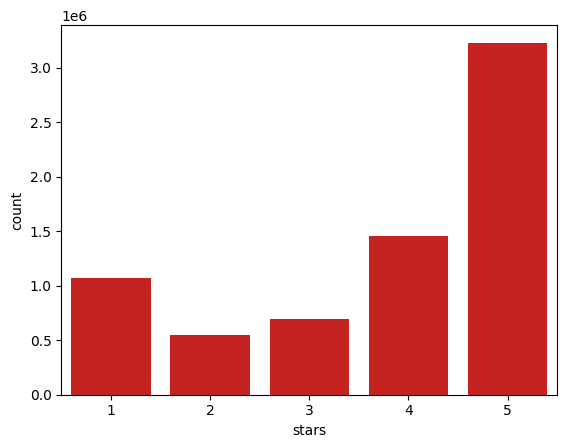

In [45]:
sns.countplot(data=review, x="stars", color=YELP_RED)

<Axes: xlabel='stars'>

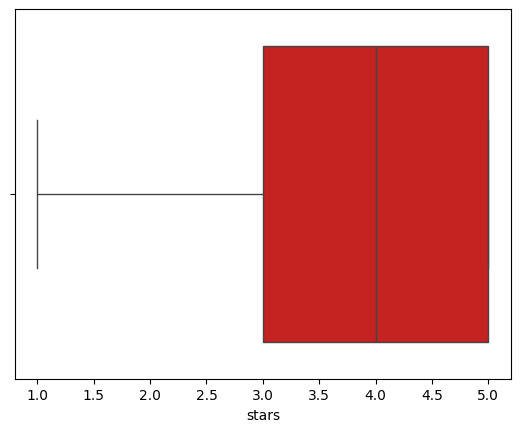

In [46]:
sns.boxplot(data=review, x="stars", color=YELP_RED)

### Useful, funny, cool

[]

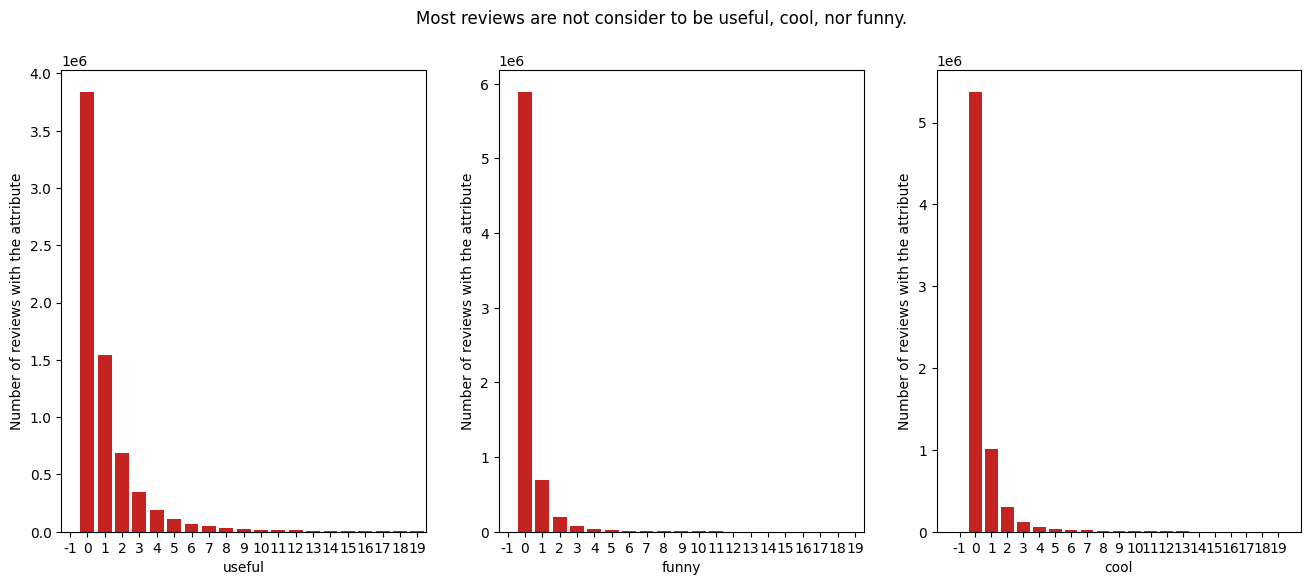

In [47]:
fig, (ax_useful, ax_funny, ax_cool) = plt.subplots(1, 3, figsize=(16, 6))
sns.countplot(data=review[review["useful"] < 20], x="useful", color=YELP_RED, ax=ax_useful)
sns.countplot(data=review[review["funny"] < 20], x="funny", color=YELP_RED, ax=ax_funny)
sns.countplot(data=review[review["cool"] < 20], x="cool", color=YELP_RED, ax=ax_cool)
for ax in ax_useful, ax_funny, ax_cool:
    ax.set_ylabel("Number of reviews with the attribute")
fig.suptitle("Most reviews are not consider to be useful, cool, nor funny.")
plt.plot()

### Text length

Text(0.5, 1.0, 'Most reviews tend to be around 200 characters long.')

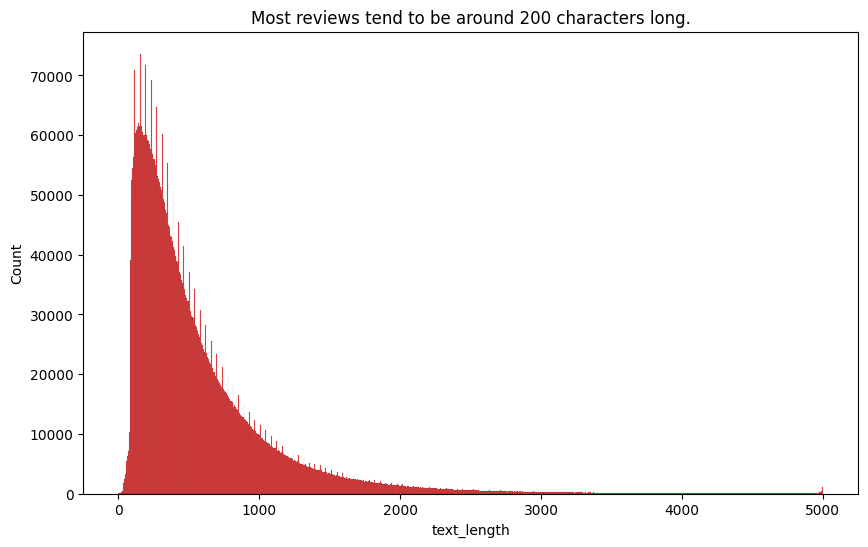

In [48]:
plt.figure(figsize=(10, 6))
fig = sns.histplot(data=review, x="text_length", color=YELP_RED)
fig.set_title("Most reviews tend to be around 200 characters long.")

Text(0.5, 1.0, 'Most reviews tend to be around 200 characters long.')

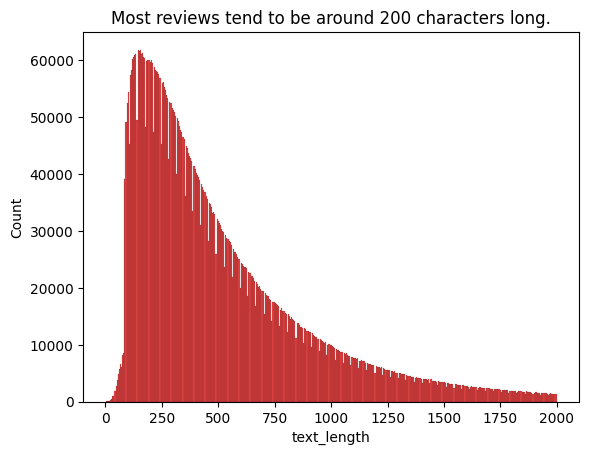

In [49]:
fig = sns.histplot(data=review[review["text_length"] < 2000], x="text_length", color=YELP_RED)
fig.set_title("Most reviews tend to be around 200 characters long.")

## Tip

In [50]:
tip = pd.read_json(DATASET_PATH / "yelp_academic_dataset_tip.json", lines=True)
tip

,user_id,business_id,text,date,compliment_count
0,AGNUgVwnZUey3gcPCJ76iw,3uLgwr0qeCNMjKenHJwPGQ,Avengers time with the ladies.,2012-05-18 02:17:21,0
1,NBN4MgHP9D3cw--SnauTkA,QoezRbYQncpRqyrLH6Iqjg,They have lots of good deserts and tasty cuban...,2013-02-05 18:35:10,0
2,-copOvldyKh1qr-vzkDEvw,MYoRNLb5chwjQe3c_k37Gg,It's open even when you think it isn't,2013-08-18 00:56:08,0
3,FjMQVZjSqY8syIO-53KFKw,hV-bABTK-glh5wj31ps_Jw,Very decent fried chicken,2017-06-27 23:05:38,0
4,ld0AperBXk1h6UbqmM80zw,_uN0OudeJ3Zl_tf6nxg5ww,Appetizers.. platter special for lunch,2012-10-06 19:43:09,0
...,...,...,...,...,...
908910,eYodOTF8pkqKPzHkcxZs-Q,3lHTewuKFt5IImbXJoFeDQ,Disappointed in one of your managers.,2021-09-11 19:18:57,0
908911,1uxtQAuJ2T5Xwa_wp7kUnA,OaGf0Dp56ARhQwIDT90w_g,Great food and service.,2021-10-30 11:54:36,0
908912,v48Spe6WEpqehsF2xQADpg,hYnMeAO77RGyTtIzUSKYzQ,Love their Cubans!!,2021-11-05 13:18:56,0
908913,ckqKGM2hl7I9Chp5IpAhkw,s2eyoTuJrcP7I_XyjdhUHQ,Great pizza great price,2021-11-20 16:11:44,0


In [51]:
tip.info()

<class 'pandas.DataFrame'>
RangeIndex: 908915 entries, 0 to 908914
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   user_id           908915 non-null  str           
 1   business_id       908915 non-null  str           
 2   text              908915 non-null  str           
 3   date              908915 non-null  datetime64[us]
 4   compliment_count  908915 non-null  int64         
dtypes: datetime64[us](1), int64(1), str(3)
memory usage: 34.7 MB


In [52]:
tip.describe()

,date,compliment_count
count,908915,908915.000000
mean,2015-06-14 10:13:53.302817,0.012525
min,2009-04-16 13:11:49,0.000000
25%,2013-01-26 01:18:02.500000,0.000000
50%,2015-03-15 01:10:25,0.000000
75%,2017-08-02 06:19:55.500000,0.000000
max,2022-01-19 20:38:55,6.000000
std,NaN,0.120763


### Compliment count

[]

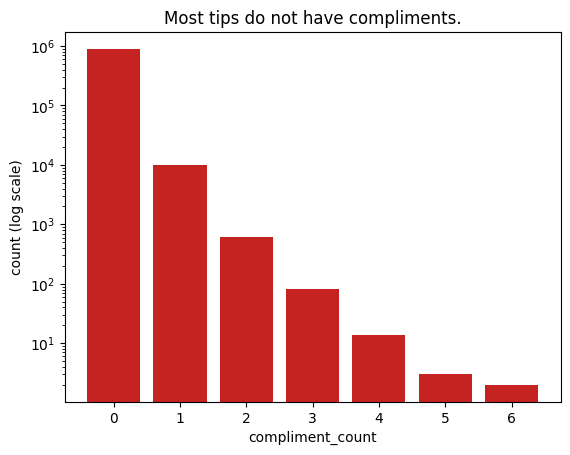

In [53]:
fig = sns.countplot(data=tip, x="compliment_count", color=YELP_RED)
fig.set_title("Most tips do not have compliments.")
fig.set_ylabel("count (log scale)")
fig.set_yscale("log")
fig.plot()

### Date

<Axes: xlabel='date', ylabel='Count'>

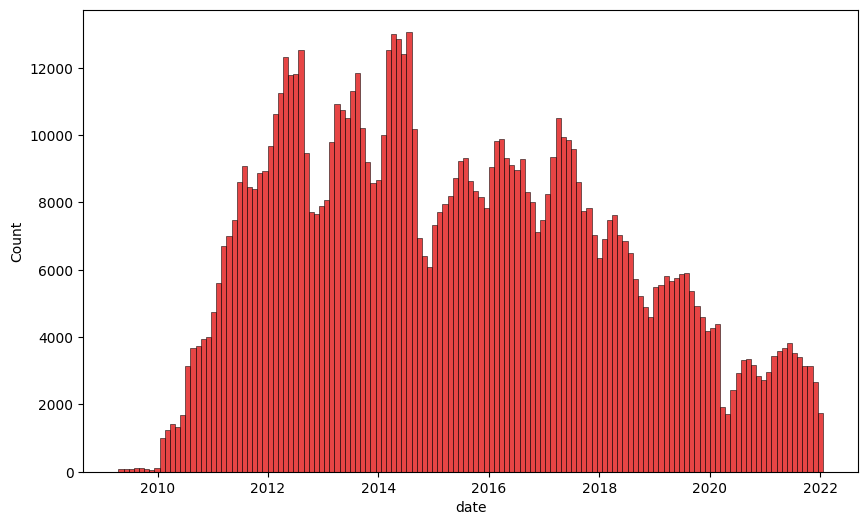

In [54]:
plt.figure(figsize=(10, 6))
sns.histplot(data=tip, x="date", color=YELP_RED)

## User

WARNING: This is a modified version users without the `friends` column.

In [55]:
user = pd.read_csv(CUSTOM_DATASET_PATH / "user_for_vis.csv")
user

,user_id,name,review_count,yelping_since,useful,funny,cool,elite,fans,average_stars,...,compliment_profile,compliment_cute,compliment_list,compliment_note,compliment_plain,compliment_cool,compliment_funny,compliment_writer,compliment_photos,number_of_friends
0,qVc8ODYU5SZjKXVBgXdI7w,Walker,585,2007-01-25 16:47:26,7217,1259,5994,2007,267,3.91,...,55,56,18,232,844,467,467,239,180,14995
1,j14WgRoU_-2ZE1aw1dXrJg,Daniel,4333,2009-01-25 04:35:42,43091,13066,27281,"2009,2010,2011,2012,2013,2014,2015,2016,2017,2...",3138,3.74,...,184,157,251,1847,7054,3131,3131,1521,1946,4646
2,2WnXYQFK0hXEoTxPtV2zvg,Steph,665,2008-07-25 10:41:00,2086,1010,1003,"2009,2010,2011,2012,2013",52,3.32,...,10,17,3,66,96,119,119,35,18,381
3,SZDeASXq7o05mMNLshsdIA,Gwen,224,2005-11-29 04:38:33,512,330,299,"2009,2010,2011",28,4.27,...,1,6,2,12,16,26,26,10,9,131
4,hA5lMy-EnncsH4JoR-hFGQ,Karen,79,2007-01-05 19:40:59,29,15,7,NaN,1,3.54,...,0,0,0,1,1,0,0,0,0,27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1987892,fB3jbHi3m0L2KgGOxBv6uw,Jerrold,23,2015-01-06 00:31:31,7,0,0,NaN,0,4.92,...,0,0,0,0,0,0,0,0,0,1
1987893,68czcr4BxJyMQ9cJBm6C7Q,Jane,1,2016-06-14 07:20:52,0,0,0,NaN,0,5.00,...,0,0,0,0,0,0,0,0,0,1
1987894,1x3KMskYxOuJCjRz70xOqQ,Shomari,4,2017-02-04 15:31:58,1,1,0,NaN,0,2.00,...,0,0,0,0,0,0,0,0,0,1
1987895,ulfGl4tdbrH05xKzh5lnog,Susanne,2,2011-01-14 00:29:08,0,0,0,NaN,0,3.00,...,0,0,0,0,0,0,0,0,0,1


In [56]:
user.info()

<class 'pandas.DataFrame'>
RangeIndex: 1987897 entries, 0 to 1987896
Data columns (total 22 columns):
 #   Column              Dtype  
---  ------              -----  
 0   user_id             str    
 1   name                str    
 2   review_count        int64  
 3   yelping_since       str    
 4   useful              int64  
 5   funny               int64  
 6   cool                int64  
 7   elite               str    
 8   fans                int64  
 9   average_stars       float64
 10  compliment_hot      int64  
 11  compliment_more     int64  
 12  compliment_profile  int64  
 13  compliment_cute     int64  
 14  compliment_list     int64  
 15  compliment_note     int64  
 16  compliment_plain    int64  
 17  compliment_cool     int64  
 18  compliment_funny    int64  
 19  compliment_writer   int64  
 20  compliment_photos   int64  
 21  number_of_friends   int64  
dtypes: float64(1), int64(17), str(4)
memory usage: 333.7 MB


In [57]:
user.describe().iloc[1:]

,review_count,useful,funny,cool,fans,average_stars,compliment_hot,compliment_more,compliment_profile,compliment_cute,compliment_list,compliment_note,compliment_plain,compliment_cool,compliment_funny,compliment_writer,compliment_photos,number_of_friends
mean,23.394409,42.296335,16.970536,23.792914,1.465740,3.630494,1.807072,0.292263,0.179318,0.133649,0.063907,1.443135,3.011841,2.829308,2.829308,1.056448,1.226859,53.375011
std,82.566992,641.480597,407.803437,565.351295,18.130753,1.183337,73.601841,12.824667,15.155253,11.356823,10.043627,60.167900,119.389804,96.663854,96.663854,32.179728,95.157513,146.443469
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,5.000000,3.000000,0.000000,0.000000,0.000000,3.880000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
75%,17.000000,13.000000,2.000000,3.000000,0.000000,4.560000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,46.000000
max,17473.000000,206296.000000,185823.000000,199878.000000,12497.000000,5.000000,25784.000000,13501.000000,14180.000000,13654.000000,12669.000000,59031.000000,101097.000000,49967.000000,49967.000000,15934.000000,82630.000000,14995.000000


[]

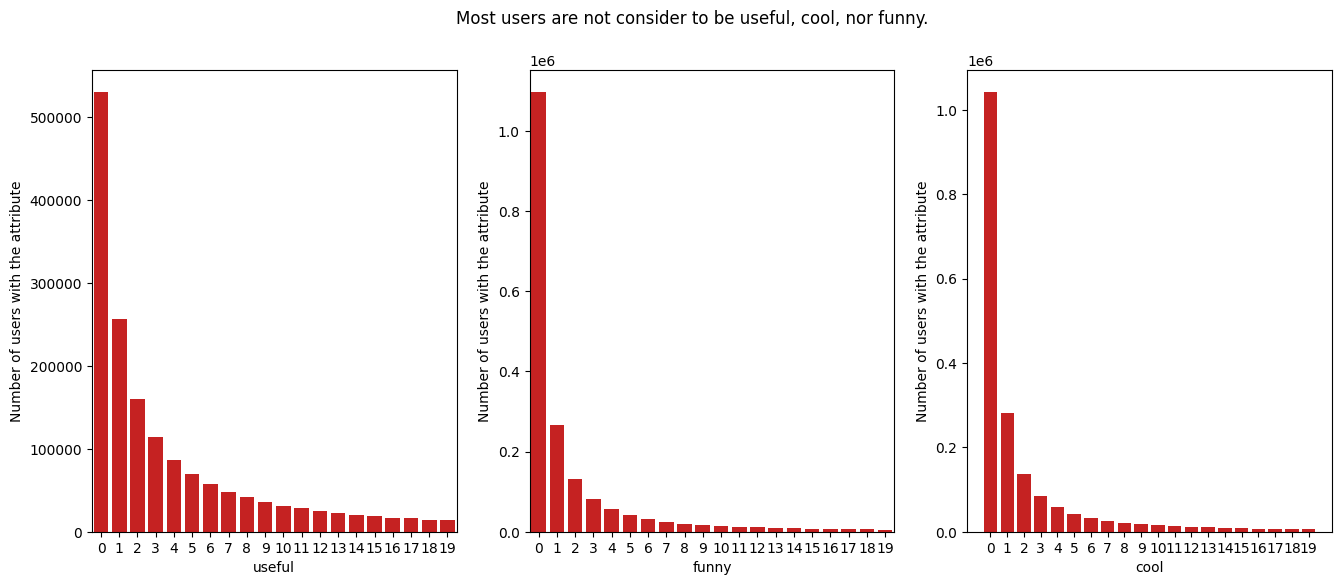

In [58]:
fig, (ax_useful, ax_funny, ax_cool) = plt.subplots(1, 3, figsize=(16, 6))
sns.countplot(data=user[user["useful"] < 20], x="useful", color=YELP_RED, ax=ax_useful)
sns.countplot(data=user[user["funny"] < 20], x="funny", color=YELP_RED, ax=ax_funny)
sns.countplot(data=user[user["cool"] < 20], x="cool", color=YELP_RED, ax=ax_cool)
for ax in ax_useful, ax_funny, ax_cool:
    ax.set_ylabel("Number of users with the attribute")
fig.suptitle("Most users are not consider to be useful, cool, nor funny.")
plt.plot()

[]

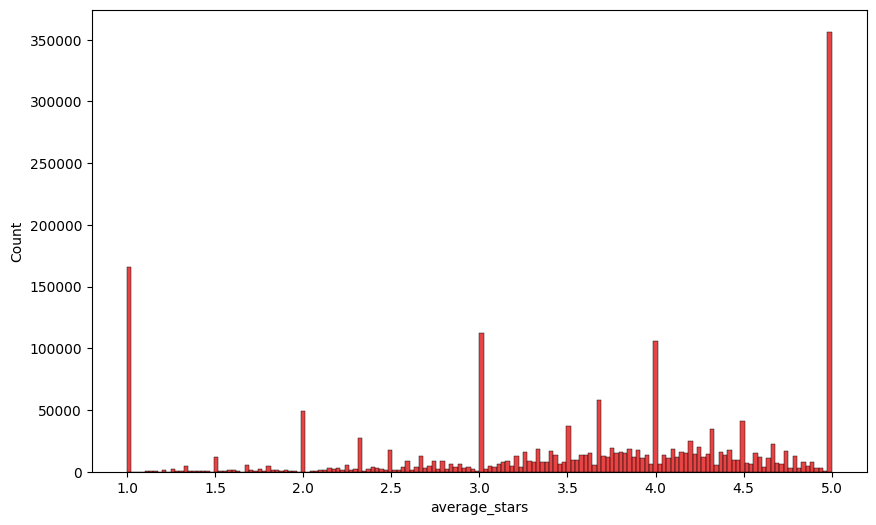

In [59]:
plt.figure(figsize=(10, 6))
sns.histplot(data=user, x="average_stars", color=YELP_RED)
plt.plot()

[]

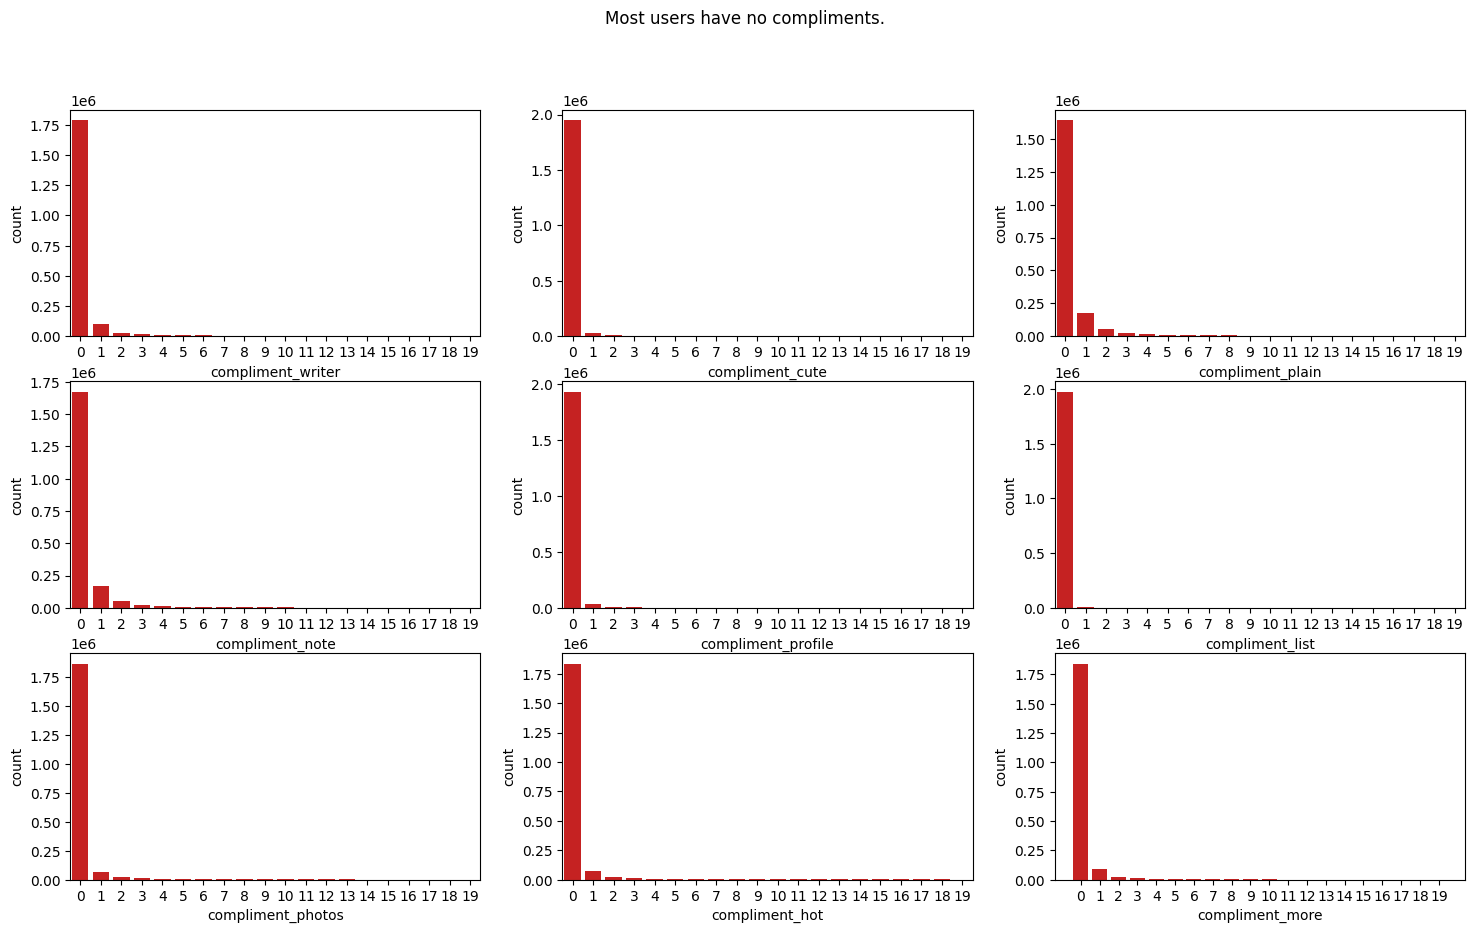

In [60]:
compliment_columns = set(user.describe().filter(like="compliment_").columns)
compliment_columns = compliment_columns - {"compliment_funny", "compliment_cool"}
fig, axes = plt.subplots(3, 3, figsize=(18, 10))
for i, compliment in enumerate(compliment_columns):
    sns.countplot(data=user[user[compliment] < 20], x=compliment, color=YELP_RED, ax=axes[i//3][i%3])
fig.suptitle("Most users have no compliments.")
plt.plot()

[]

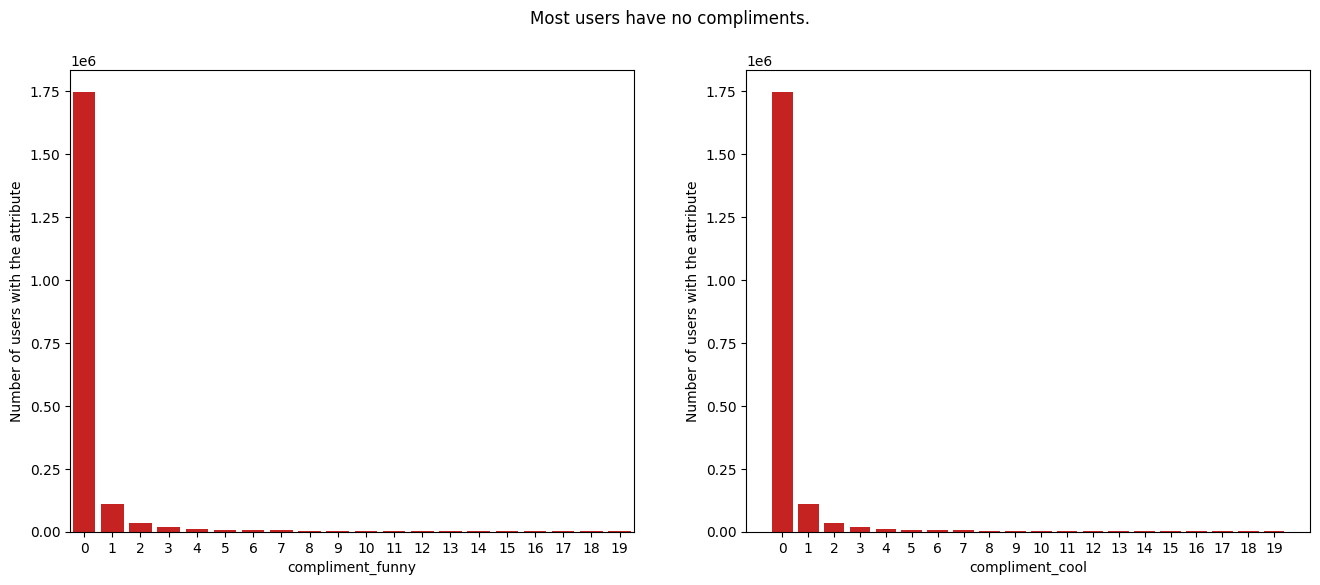

In [61]:
compliment_columns = {"compliment_funny", "compliment_cool"}
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for i, compliment in enumerate(compliment_columns):
    sns.countplot(data=user[user[compliment] < 20], x=compliment, color=YELP_RED, ax=axes[i])
for ax in axes:
    ax.set_ylabel("Number of users with the attribute")
fig.suptitle("Most users have no compliments.")
plt.plot()

[]

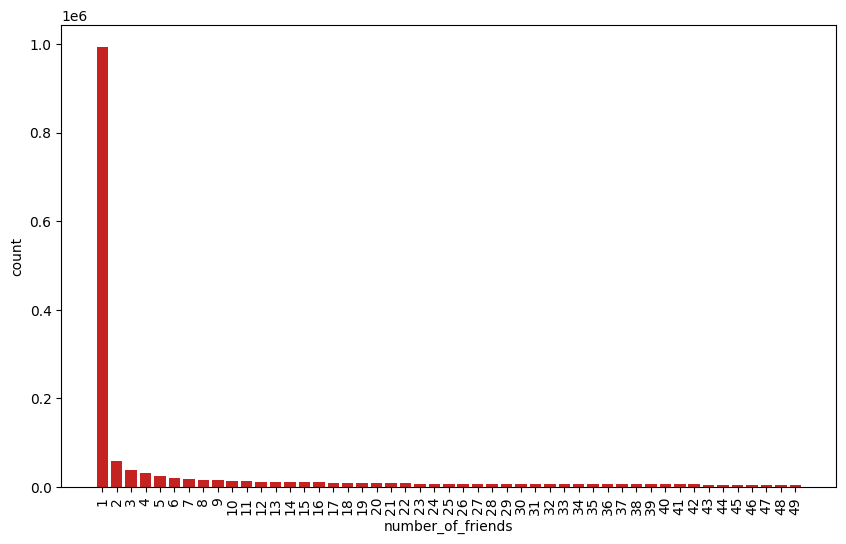

In [62]:
plt.figure(figsize=(10, 6))
sns.countplot(data=user[user["number_of_friends"] < 50], x="number_of_friends", color=YELP_RED)
plt.xticks(rotation=90)
fig.suptitle("Most users have just a single friend.")
plt.plot()

### yelping since

In [63]:
timestamp_format = "%Y-%m-%d %H:%M:%S"
yelping_sinces = [datetime.datetime.strptime(timestamp, timestamp_format).date() for timestamp in user["yelping_since"].tolist()]

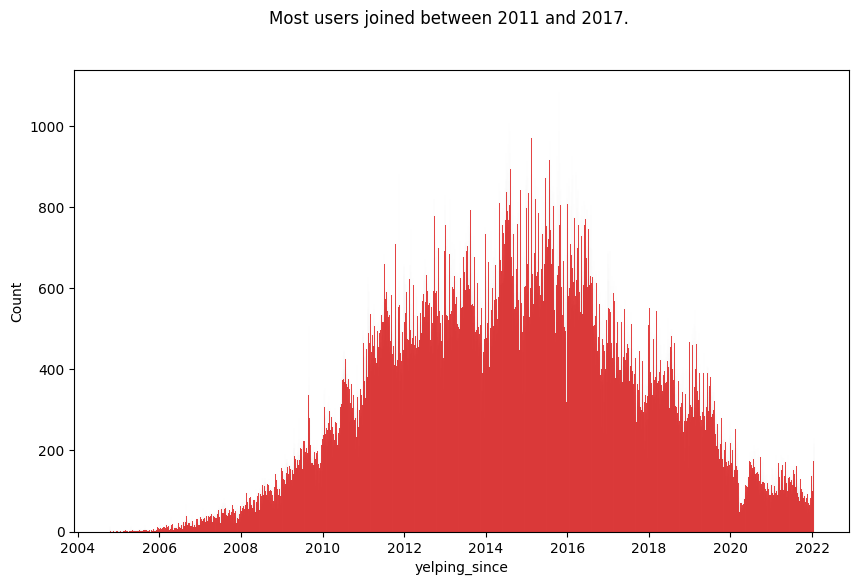

In [64]:
plt.figure(figsize=(10, 6))
fig = sns.histplot(data=yelping_sinces, color=YELP_RED)
fig.set_xlabel("yelping_since")
plt.suptitle("Most users joined between 2011 and 2017.")
plt.show()

### Elite

In [65]:
print("NaNs (%) in elite column:", 100 * float(user["elite"].isna().sum() / user["elite"].shape[0]))

NaNs (%) in elite column: 95.41233776196654


### Fans

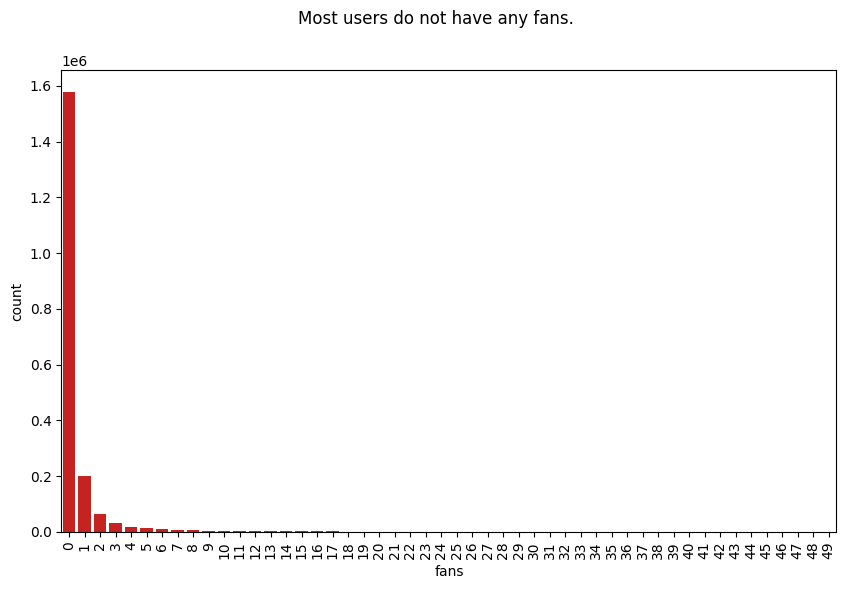

In [66]:
plt.figure(figsize=(10, 6))
fig = sns.countplot(data=user[user["fans"] < 50], x="fans", color=YELP_RED)
plt.xticks(rotation=90)
plt.suptitle("Most users do not have any fans.")
plt.show()

- 1.zad = user matica (collaborative / hybrid = prve dva / tri notebooky z week_02) / sekvencne (asi by sme predikovali checkin? TOTO URCITE NIE, chyba user_id)
- 2.zad = deep learning

pri druhom zadani este teoreticky mozeme zmenit dataset, ak by nevyhovoval

podla priemerneho poctu recenzii v mestach (alebo poctu hviezdiciek)
pomocou LLM vytiahnut z recenzii booleany o zakaznikoch (preferuje_nizke_ceny, ma_rad_taliansku_kuchynu)
checkiny mozeme ignorovat
ak si zvolime businessy, co maju malo recenzii (vacsina ma od 5 do 15), tak nemozeme robit time-weighted recommendation ako v ElasticSearch
datumy recenzii mozeme vyhodit ak nebudeme robit time weight-based boost (asi nebudeme malo recenzii)



CHECKIN preč!

mozeme analyzovat aj tipy (zatiaľ; ak z nich nič nebude, tak ich vyhodíme)

opening / closing (mozno cez rozdiel closing - opening este zistime)
este poriesit atributy, je tam vela chybajucich hodnot (1 = true, 0 = false, 0.5 = nan??)
geoudaje okrem mesta a štátu definitivne vyhodit
postal code a meno businessu tiez nemusime riesit

is_open = 0 vyhodit
elite z userov vyhodit
useful, funny a cool z userov vyhodit, vacsina ma aj tak 0
average_stars moze ist prec
complimenty prec, z businesses tiez vyhodit useful, funny, cool
number_of_friends moze ist prec (friends ako taki asi tiez)
este by som mozno do dokumentacie NEZABUDOL napisat, ze sme neriesili photos.json